In [1]:
# gw-loss-main.ipynb

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import anndata as ad
import logging
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns
import sys

In [4]:
in_dir = "/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/simulator_evaluation/rs_benchmark/baf/gene/base/gw-loss/pp"
out_stat_dir = "/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/simulator_evaluation/rs_benchmark/baf/gene/base/gw-loss/stats"
out_fig_dir = "/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/simulator_evaluation/rs_benchmark/baf/gene/base/gw-loss/figures"

In [5]:
utils_dir = "/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/simulator_evaluation/rs_benchmark/baf/gene/base/scripts"
sys.path.append(utils_dir)
from ubase import *
from ubaf import *
from urdr import stat_stack_zeroprop, stat_LR

In [6]:
os.makedirs(out_stat_dir, exist_ok = True)
os.makedirs(out_fig_dir, exist_ok = True)

In [7]:
cw_prefix = 'cw-'
gw_prefix = 'gw-'

dpi = 300

In [8]:
blue = '#0072B2'
orange = '#E69F00'
green = '#009E73'
red = '#D55E00'     # Vermillion

def_color = blue

In [9]:
tool_labels = ['seed_N', 'stCNASim-rs_N', 'scReadSim-cna_N', 'stCNASim-rs_T', 'scReadSim-cna_T']
tool_palette = {
    'seed_N': orange,
    'stCNASim-rs_N': '#56B4E9',
    'scReadSim-cna_N': green,
    'stCNASim-rs_T': '#F0E442',
    'scReadSim-cna_T': blue
}

# Load Data

In [10]:
seed_normal_fn = os.path.join(in_dir, "seed_normal.h5ad")
rs_normal_fn = os.path.join(in_dir, "rs_normal.h5ad")
rs_tumor_fn = os.path.join(in_dir, "rs_tumor.h5ad")
scrs_normal_fn = os.path.join(in_dir, "scrs_normal.h5ad")
scrs_tumor_fn = os.path.join(in_dir, "scrs_tumor.h5ad")

In [11]:
seed_normal = ad.read_h5ad(seed_normal_fn)
print(seed_normal)

rs_normal = ad.read_h5ad(rs_normal_fn)
print(rs_normal)

rs_tumor = ad.read_h5ad(rs_tumor_fn)
print(rs_tumor)

scrs_normal = ad.read_h5ad(scrs_normal_fn)
print(scrs_normal)

scrs_tumor = ad.read_h5ad(scrs_tumor_fn)
print(scrs_tumor)

AnnData object with n_obs × n_vars = 600 × 1438
    obs: 'cell', 'cell_type'
    var: 'chrom', 'start', 'end', 'feature', 'strand'
    layers: 'A', 'B', 'U'
AnnData object with n_obs × n_vars = 600 × 1438
    obs: 'cell', 'cell_type'
    var: 'chrom', 'start', 'end', 'feature', 'strand'
    layers: 'A', 'B', 'U'
AnnData object with n_obs × n_vars = 600 × 1438
    obs: 'cell', 'cell_type'
    var: 'chrom', 'start', 'end', 'feature', 'strand'
    layers: 'A', 'B', 'U'
AnnData object with n_obs × n_vars = 600 × 1438
    obs: 'cell', 'cell_type'
    var: 'chrom', 'start', 'end', 'feature', 'strand'
    layers: 'A', 'B', 'U'
AnnData object with n_obs × n_vars = 600 × 1438
    obs: 'cell', 'cell_type'
    var: 'chrom', 'start', 'end', 'feature', 'strand'
    layers: 'A', 'B', 'U'


# Gene-wise Metrics

In [12]:
mv = get_gw_metrics_group(
    adata_lst = [seed_normal, rs_normal, scrs_normal, rs_tumor, scrs_tumor],
    X_names = tool_labels,
    id_lst = [seed_normal.var['feature'].to_numpy(), rs_normal.var['feature'].to_numpy(), scrs_normal.var['feature'].to_numpy(),
             rs_tumor.var['feature'].to_numpy(), scrs_tumor.var['feature'].to_numpy()],
    metrics = ["mean", "var", "cv", "zero_prop", "sum"]
)
mv = mv.rename(columns = dict(X_name = 'group'))
mv

,mean_A,var_A,cv_A,zero_prop_A,sum_A,X_name_A,feature_A,mean_B,var_B,cv_B,...,var_ABU,cv_ABU,zero_prop_ABU,sum_ABU,X_name_ABU,feature_ABU,group,feature,DP,baf
0,0.001667,0.001664,24.474475,0.998333,1,seed_N,DCUN1D4,0.0,0.0,0.0,...,0.274197,1.881336,0.756667,167,seed_N,DCUN1D4,seed_N,DCUN1D4,1,0.0
1,0.000000,0.000000,0.000000,1.000000,0,seed_N,AC027271.1,0.0,0.0,0.0,...,0.008264,10.908712,0.991667,5,seed_N,AC027271.1,seed_N,AC027271.1,0,NaN
2,0.000000,0.000000,0.000000,1.000000,0,seed_N,LRRC66,0.0,0.0,0.0,...,0.000000,0.000000,1.000000,0,seed_N,LRRC66,seed_N,LRRC66,0,NaN
3,0.000000,0.000000,0.000000,1.000000,0,seed_N,SGCB,0.0,0.0,0.0,...,0.202864,2.391526,0.835000,113,seed_N,SGCB,seed_N,SGCB,0,NaN
4,0.000000,0.000000,0.000000,1.000000,0,seed_N,LINC02480,0.0,0.0,0.0,...,0.000000,0.000000,1.000000,0,seed_N,LINC02480,seed_N,LINC02480,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7185,0.001667,0.001664,24.474475,0.998333,1,scReadSim-cna_T,HOOK3,0.0,0.0,0.0,...,0.125108,3.075709,0.896667,69,scReadSim-cna_T,HOOK3,scReadSim-cna_T,HOOK3,1,0.0
7186,0.000000,0.000000,0.000000,1.000000,0,scReadSim-cna_T,AC110275.1,0.0,0.0,0.0,...,0.000000,0.000000,1.000000,0,scReadSim-cna_T,AC110275.1,scReadSim-cna_T,AC110275.1,0,NaN
7187,0.000000,0.000000,0.000000,1.000000,0,scReadSim-cna_T,FNTA,0.0,0.0,0.0,...,0.145864,2.760877,0.875000,83,scReadSim-cna_T,FNTA,scReadSim-cna_T,FNTA,0,NaN
7188,0.000000,0.000000,0.000000,1.000000,0,scReadSim-cna_T,POMK,0.0,0.0,0.0,...,0.001664,24.474475,0.998333,1,scReadSim-cna_T,POMK,scReadSim-cna_T,POMK,0,NaN


In [13]:
tmp = mv.copy()

tmp.to_csv(
    os.path.join(out_stat_dir, gw_prefix + "metric_values.tsv"), 
    header = True, 
    index = False, 
    sep = "\t"
)

In [14]:
np.log10(mv['mean_ABU'].min() + 1), np.log10(mv['mean_ABU'].max() + 1)

(0.0, 3.0938907499919823)

In [15]:
np.log10(mv['mean_AB'].min() + 1), np.log10(mv['mean_AB'].max() + 1)

(0.0, 0.9393528243805582)

In [16]:
np.log10(mv['DP'].min() + 1), np.log10(mv['DP'].max() + 1)

(0.0, 3.6645479622465467)

## Single Metric

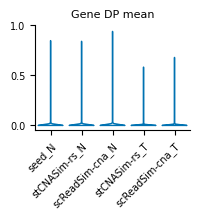

In [17]:
fig = plt.figure(figsize = (2.1, 2.3))

x = mv['group']
y = mv['mean_AB']
y = np.log10(y + 1)
ax = sns.violinplot(
    x = x, y = y, 
    fill = False, 
    palette = [def_color] * len(tool_labels), 
    hue = x, 
    legend = False,
    inner = None,
    cut = 0,
    linewidth = 1.0
)
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(
    ax.get_xticklabels(), 
    rotation = 45, rotation_mode = "anchor",
    ha = 'right', fontsize = 7
)
ax.set_yticks([0, 0.5, 1])
ax.set_yticklabels(
    ax.get_yticklabels(), 
    fontsize = 7
)
ax.set_xlabel(None)
ax.set_ylabel(None)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
plt.title(r"Gene DP mean", fontsize = 8)

plt.tight_layout()
fn = os.path.join(out_fig_dir, gw_prefix + "DP-mean.png")
fig.savefig(fn, dpi = 300)

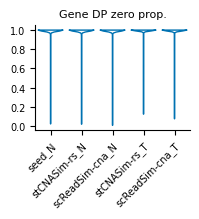

In [18]:
fig = plt.figure(figsize = (2.1, 2.3))

x = mv['group']
y = mv['zero_prop_AB']
ax = sns.violinplot(
    x = x, y = y, 
    fill = False, 
    palette = [def_color] * len(tool_labels), 
    hue = x, 
    legend = False,
    inner = None,
    cut = 0,
    linewidth = 1.0
)
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(
    ax.get_xticklabels(), 
    rotation = 45, rotation_mode = "anchor",
    ha = 'right', fontsize = 7
)
ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(
    ax.get_yticklabels(), 
    fontsize = 7
)
ax.set_xlabel(None)
ax.set_ylabel(None)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
plt.title(r"Gene DP zero prop.", fontsize = 8)

plt.tight_layout()
fn = os.path.join(out_fig_dir, gw_prefix + "DP-zero_prop.png")
fig.savefig(fn, dpi = 300)

### Percentage of genes within specific ranges of zero proportions

In [19]:
st_zeroprop = stat_stack_zeroprop(
    data = mv, 
    metric = "zero_prop_AB",
    group = "group", 
    cutoffs = [.9, .99, 1.01], 
    labels = ["[0, 0.9)", "[0.9, 0.99)", "[0.99, 1]"]
)
print(st_zeroprop)


tmp = st_zeroprop[["group", "cutoff", "label", "percent"]]
tmp.to_csv(
    os.path.join(out_stat_dir, gw_prefix + "DP-perc-of-genes-on-zero_prop.tsv"), 
    header = True, 
    index = False, 
    sep = "\t"
)

              group  level_1  cutoff        label    percent
0            seed_N        0    0.90     [0, 0.9)   1.043115
1            seed_N        1    0.99  [0.9, 0.99)   3.685675
2            seed_N        2    1.01    [0.99, 1]  95.271210
3     stCNASim-rs_N        0    0.90     [0, 0.9)   0.973574
4     stCNASim-rs_N        1    0.99  [0.9, 0.99)   3.963839
5     stCNASim-rs_N        2    1.01    [0.99, 1]  95.062587
6   scReadSim-cna_N        0    0.90     [0, 0.9)   1.112656
7   scReadSim-cna_N        1    0.99  [0.9, 0.99)   3.824757
8   scReadSim-cna_N        2    1.01    [0.99, 1]  95.062587
9     stCNASim-rs_T        0    0.90     [0, 0.9)   0.556328
10    stCNASim-rs_T        1    0.99  [0.9, 0.99)   3.129346
11    stCNASim-rs_T        2    1.01    [0.99, 1]  96.314325
12  scReadSim-cna_T        0    0.90     [0, 0.9)   0.625869
13  scReadSim-cna_T        1    0.99  [0.9, 0.99)   3.268428
14  scReadSim-cna_T        2    1.01    [0.99, 1]  96.105702


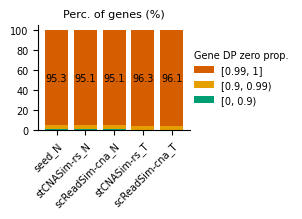

In [20]:
data = st_zeroprop
x, y, hue = 'group', 'percent', 'label'
min_v = 5
font_size = 7
colors = [green, orange, red]

# prepare data.
df = long2wide(data, index = x, columns = hue, values = y)
df[x] = df.index
hue_groups = data[hue].unique()
cumsum = np.array([0.0] * df.shape[0])

# plot.
fig = plt.figure(figsize = (3.1, 2.3))

for i, h in enumerate(hue_groups):
    if i == 0:
        plt.bar(df[x], df[h], label = h, color = colors[i])
    else:
        ax = plt.gca()
        ax.bar(df[x], df[h], label = h, bottom = cumsum, color = colors[i])
    cumsum += df[h]
        
for c in ax.containers:
    labels = [str(round(v.get_height(), 1))    \
                if v.get_height() > min_v else '' for v in c]
    ax.bar_label(c, label_type = 'center', labels = labels, 
                    fontsize = font_size, color = 'black')

ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(
    ax.get_xticklabels(), 
    rotation = 45, rotation_mode = "anchor",
    ha = 'right', fontsize = 7
)
ax.set_yticks([0, 20, 40, 60, 80, 100])
ax.set_yticklabels(
    ax.get_yticklabels(), 
    fontsize = 7
)
ax.set_ylabel("")
ax.set_xlabel("")

handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles = handles[::-1],
    labels = labels[::-1],
    title = "Gene DP zero prop.",
    loc = 'center left',
    bbox_to_anchor = [0.97, 0.5],
    title_fontsize = font_size,
    fontsize = font_size,
    alignment = 'left',
    frameon = False
)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
plt.title(r"Perc. of genes (%)", fontsize = 8)

plt.tight_layout()
fn = os.path.join(out_fig_dir, gw_prefix + "DP-perc-of-genes-on-zero_prop.png")
fig.savefig(fn, dpi = 300)

### BAF

In [21]:
mv_ind, idx_ind = remove_nan_baf(mv, how = 'independent')
print(mv_ind)

        mean_A     var_A       cv_A  zero_prop_A  sum_A         X_name_A  \
0     0.001667  0.001664  24.474475     0.998333      1           seed_N   
14    0.001667  0.001664  24.474475     0.998333      1           seed_N   
33    0.020000  0.022933   7.571878     0.981667     12           seed_N   
35    0.008333  0.008264  10.908712     0.991667      5           seed_N   
41    0.030000  0.032433   6.003086     0.971667     18           seed_N   
...        ...       ...        ...          ...    ...              ...   
7132  0.003333  0.003322  17.291616     0.996667      2  scReadSim-cna_T   
7157  0.023333  0.026122   6.926730     0.978333     14  scReadSim-cna_T   
7170  0.003333  0.003322  17.291616     0.996667      2  scReadSim-cna_T   
7184  0.000000  0.000000   0.000000     1.000000      0  scReadSim-cna_T   
7185  0.001667  0.001664  24.474475     0.998333      1  scReadSim-cna_T   

     feature_A    mean_B     var_B       cv_B  ...   var_ABU    cv_ABU  \
0      DCUN1D

In [22]:
tmp = mv_ind.copy()
tmp.to_csv(
    os.path.join(out_stat_dir, gw_prefix + "metric_values-filter_nan_independent.tsv"), 
    header = True, 
    index = False, 
    sep = "\t"
)

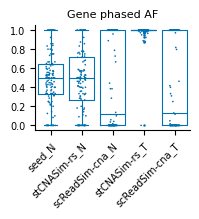

In [23]:
fig = plt.figure(figsize = (2.1, 2.3))

x = mv_ind['group']
y = mv_ind['baf']
ax = sns.boxplot(
    x = x, y = y, 
    fill = False, 
    palette = [def_color] * len(tool_labels), 
    hue = x, 
    legend = False,
    showfliers = True,
    fliersize = 0.8,
    linewidth = 0.8
)
sns.stripplot(
    x = x, y = y, 
    palette = [def_color] * len(tool_labels), 
    hue = x, 
    legend = False, 
    ax = ax,
    size = 1.2, 
    jitter = 0.15
)
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(
    ax.get_xticklabels(), 
    rotation = 45, rotation_mode = "anchor",
    ha = 'right', fontsize = 7
)
ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(
    ax.get_yticklabels(), 
    fontsize = 7
)
ax.set_xlabel(None)
ax.set_ylabel(None)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
plt.title(r"Gene phased AF", fontsize = 8)

plt.tight_layout()
fn = os.path.join(out_fig_dir, gw_prefix + "baf.png")
fig.savefig(fn, dpi = 300)

## Linear Regression

In [24]:
pairs = [
    ("stCNASim-rs_N", "seed_N"),
    ("scReadSim-cna_N", "seed_N"),
    ("stCNASim-rs_N", "scReadSim-cna_N"),
    ("stCNASim-rs_T", "scReadSim-cna_T")
]

selected_gvars = pd.DataFrame(data = dict(
    x = [p[1] for p in pairs],
    y = [p[0] for p in pairs],
))

In [25]:
mv_isec, idx_isec = remove_nan_baf(mv, how = 'intersect')
print(mv_isec)


tmp = mv_isec.copy()
tmp.to_csv(
    os.path.join(out_stat_dir, gw_prefix + "metric_values-filter_nan_intersect.tsv"), 
    header = True, 
    index = False, 
    sep = "\t"
)

        mean_A     var_A       cv_A  zero_prop_A  sum_A         X_name_A  \
33    0.020000  0.022933   7.571878     0.981667     12           seed_N   
35    0.008333  0.008264  10.908712     0.991667      5           seed_N   
41    0.030000  0.032433   6.003086     0.971667     18           seed_N   
44    0.000000  0.000000   0.000000     1.000000      0           seed_N   
48    0.095000  0.102642   3.372393     0.913333     57           seed_N   
...        ...       ...        ...          ...    ...              ...   
7051  0.000000  0.000000   0.000000     1.000000      0  scReadSim-cna_T   
7132  0.003333  0.003322  17.291616     0.996667      2  scReadSim-cna_T   
7157  0.023333  0.026122   6.926730     0.978333     14  scReadSim-cna_T   
7170  0.003333  0.003322  17.291616     0.996667      2  scReadSim-cna_T   
7185  0.001667  0.001664  24.474475     0.998333      1  scReadSim-cna_T   

     feature_A    mean_B     var_B       cv_B  ...   var_ABU    cv_ABU  \
33      SRD5A

In [26]:
st_lr = stat_LR(
    data = mv_isec,
    metric = "baf", group = "group", gvars = selected_gvars, 
    log_scale = True
)
print(st_lr)

tmp = st_lr.copy()
tmp.to_csv(
    os.path.join(out_stat_dir, gw_prefix + "baf-lr-stat.tsv"), 
    header = True, 
    index = False, 
    sep = "\t"
)

                 x                y         a         b        r2  \
0           seed_N    stCNASim-rs_N  1.054717 -0.017781  0.615298   
1           seed_N  scReadSim-cna_N  0.224440  0.082889  0.008298   
2  scReadSim-cna_N    stCNASim-rs_N  0.058299  0.167296  0.011412   
3  scReadSim-cna_T    stCNASim-rs_T  0.016327  0.294680  0.005733   

        p_value  
0  2.032613e-21  
1  3.748812e-01  
2  2.976528e-01  
3  4.610489e-01  


In [27]:
df_baf = long2wide(mv_isec, columns = 'group', values = 'baf', index = 'feature')
print(df_baf)

tmp = df_baf.copy()
tmp.to_csv(
    os.path.join(out_stat_dir, gw_prefix + "baf-lr.tsv"), 
    header = True, 
    index = True, 
    sep = "\t"
)

group      seed_N  stCNASim-rs_N  scReadSim-cna_N  stCNASim-rs_T  \
feature                                                            
SRD5A3   0.555556       0.552632         0.000000       1.000000   
TMEM165  0.642857       0.500000         0.000000       1.000000   
EXOC1    0.470588       0.678571         0.035714       1.000000   
AASDH    1.000000       1.000000         1.000000       1.000000   
PAICS    0.400000       0.322917         1.000000       1.000000   
...           ...            ...              ...            ...   
SARAF    0.528073       0.527301         0.998563       0.996979   
TACC1    0.666667       1.000000         0.000000       1.000000   
GOLGA7   0.838710       0.774194         0.000000       1.000000   
AP3M2    0.500000       0.333333         0.000000       1.000000   
HOOK3    1.000000       1.000000         0.000000       1.000000   

group    scReadSim-cna_T  
feature                   
SRD5A3          0.000000  
TMEM165         0.000000  
EXOC1  

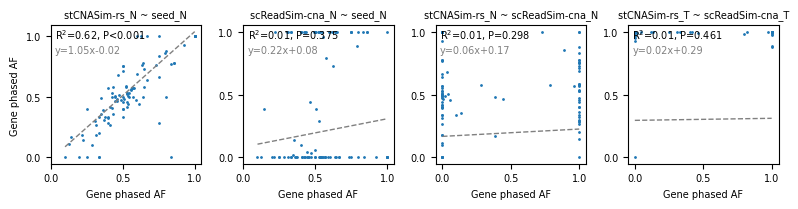

In [28]:
ncols = 4
fig, axs = plt.subplots(nrows = 1, ncols = ncols, figsize = (8.0, 2.2))

pos_r = (.03, .9)
pos_fit = (.03, .8)
fit_kws = dict()
fontsize = 7

columns = np.asarray(df_baf.columns)
df = df_baf[columns].copy()

gvars = st_lr[['x', 'y']].copy()
k = 0
for i in range(gvars.shape[0]):
    ax = axs.flat[k]
    cx = gvars['x'].loc[i]
    cy = gvars['y'].loc[i]
    d = st_lr.loc[(st_lr['x'] == cx) & (st_lr['y'] == cy)]
    assert d.shape[0] == 1
    a = d['a'].iloc[0]
    b = d['b'].iloc[0]
    r2 = d['r2'].iloc[0]
    p_value = d['p_value'].iloc[0]

    x, y = df[cx], df[cy]
    ax.plot(x, y, marker = '.', markersize = 2, linestyle = 'none')
    x_vals = np.linspace(max(ax.get_xlim()[0], np.min(x)), 
                        min(ax.get_xlim()[1], np.max(x)), 100)

    color_fit = fit_kws.get('color', 'gray')
    ax.plot(
        x_vals, a*x_vals+b, 
        linestyle = fit_kws.get('linestyle', '--'), 
        color = color_fit, 
        linewidth = fit_kws.get('linewidth', 1.0)
    )
    equation_str = format_equation(a, b)
    ax.annotate(equation_str, xy = pos_fit, xycoords = ax.transAxes,
                color = color_fit, fontsize = fontsize)
    pv_str = format_pvalue(p_value) 
    ax.annotate(r"R$^2$=%.2f, %s" % (r2, pv_str), xy = pos_r, 
                xycoords = ax.transAxes, fontsize = fontsize)

    ax.set_title(None)
    ax.set_xlabel("Gene phased AF", fontsize = fontsize)
    if k % ncols == 0:
        ax.set_ylabel("Gene phased AF", fontsize = fontsize)
    ax.set_title(cy + ' ~ ' + cx, fontsize = fontsize)
    ax.set_xticks([0, 0.5, 1])
    ax.set_xticklabels(
        ax.get_xticklabels(), 
        fontsize = fontsize
    )
    ax.set_yticks([0, 0.5, 1])
    ax.set_yticklabels(
        ax.get_yticklabels(), 
        fontsize = fontsize
    )
    k += 1

for ax in axs:
    for s in ["top", "right"]:
        ax.spines[s].set_visible(True)
        
plt.tight_layout()
fn = os.path.join(out_fig_dir, gw_prefix + "baf-lr.png")
fig.savefig(fn, dpi = 300)

### BAF vs. Mean

In [29]:
selected_gvars = ['seed_N', 'stCNASim-rs_N', 'scReadSim-cna_N', 'stCNASim-rs_T', 'scReadSim-cna_T']

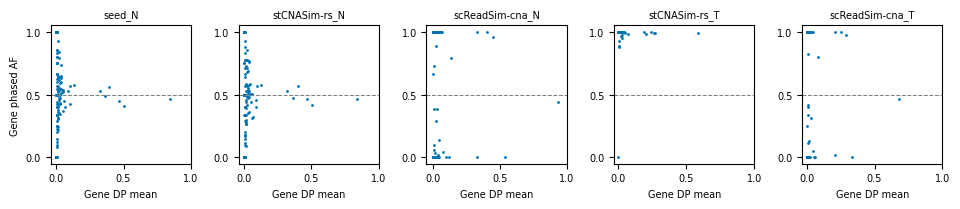

In [30]:
ncols = 5
fig, axs = plt.subplots(nrows = 1, ncols = ncols, figsize = (9.7, 2.2))

fontsize = 7

gvars = selected_gvars
k = 0
for i in range(len(gvars)):
    ax = axs[k]
    cx = gvars[i]
    df = mv_ind.loc[mv_ind['group'] == cx].copy()

    vx = df['mean_AB'].to_numpy()
    vy = df['baf'].to_numpy()
    vx = np.log10(vx + 1)
    
    ax.plot(vx, vy, marker = '.', markersize = 2, 
            linestyle = 'none', color = def_color)

    ref_kws = dict()
    ax.axhline(
        y = ref_kws.get('y', 0.5), 
        linestyle = ref_kws.get('linestyle', '--'), 
        linewidth = ref_kws.get('linewidth', 0.75),
        color = ref_kws.get('color', 'gray')
    )
    ax.set_xticks([0, 0.5, 1])
    ax.set_xticklabels(
        ax.get_xticklabels(), 
        fontsize = fontsize
    )
    ax.set_yticks([0, 0.5, 1])
    ax.set_yticklabels(
        ax.get_yticklabels(), 
        fontsize = fontsize
    )
    ax.set_xlabel("Gene DP mean", fontsize = fontsize)
    if k % ncols == 0:
        ax.set_ylabel("Gene phased AF", fontsize = fontsize)
    ax.set_title(cx, fontsize = fontsize)
    k += 1

for ax in axs:
    for s in ["top", "right"]:
        ax.spines[s].set_visible(True)
        
plt.tight_layout()
fn = os.path.join(out_fig_dir, gw_prefix + "baf-vs-DP-mean.png")
fig.savefig(fn, dpi = 300)